# **Project Title: Predicting divorce**
by Kabir, Rodrigue and Sertac

**Research main objective**

This project aims to develop and validate predictive models of divorce using multidimensional determinants (demographic, socioeconomic, relational, and psychological characteristics), and to identify the key factors that most strongly contribute to marital dissolution. 

Specifically, it seeks at 

-	Training and comparing multiple supervised learning models predicting divorce
-	Identifiy the most important predictors of divorce


**Research questions**

- Which supervised machine-learning model and deep learning models offers the most reliable and robust prediction of divorce?
-	Which factors contribute most to predicting divorce ?


**Methods**
-	Exploration of the dataset 
-	Preparation of the dataset
-	Training and comparison of supervised learning models
-	Identification of  the most important predictors of divorce


In [1]:
#Load libraries that will be used throughout the project (will be continuouysly updated)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier, XGBRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder 
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    roc_auc_score,
    roc_curve,
    auc
)
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.utils.data as data
from torch.utils.data import DataLoader, TensorDataset
from pytorch_tabnet.tab_model import TabNetClassifier




In [2]:
# Load the dataset
df = pd.read_csv('divorce_df.csv')
df.head()

,age_at_marriage,marriage_duration_years,num_children,education_level,employment_status,combined_income,religious_compatibility,cultural_background_match,communication_score,conflict_frequency,...,mental_health_issues,infidelity_occurred,counseling_attended,social_support,shared_hobbies_count,marriage_type,pre_marital_cohabitation,domestic_violence_history,trust_score,divorced
0,30,1,1,Bachelor,Full-time,64001,Different Religion,Yes,5.536016,3,...,No,No,No,8.428183,5,Love,Yes,No,6.262411,1
1,27,2,2,Master,Full-time,86221,Same Religion,Yes,5.810172,3,...,No,Yes,No,5.297221,1,Love,Yes,No,6.769384,1
2,31,6,0,High School,Part-time,69441,Same Religion,No,6.088146,3,...,No,No,No,5.887066,1,Arranged,Yes,No,5.532866,1
3,35,3,2,Bachelor,Full-time,69513,Not Religious,Yes,6.212046,3,...,No,No,No,5.263555,5,Love,Yes,No,3.491264,0
4,26,2,2,No Formal Education,Full-time,63986,Different Religion,Yes,4.826262,1,...,No,No,Yes,5.771259,4,Love,Yes,No,10.000000,1


In [3]:
# Make a copy of the original dataset
df1 = df.copy()
df1.head()

,age_at_marriage,marriage_duration_years,num_children,education_level,employment_status,combined_income,religious_compatibility,cultural_background_match,communication_score,conflict_frequency,...,mental_health_issues,infidelity_occurred,counseling_attended,social_support,shared_hobbies_count,marriage_type,pre_marital_cohabitation,domestic_violence_history,trust_score,divorced
0,30,1,1,Bachelor,Full-time,64001,Different Religion,Yes,5.536016,3,...,No,No,No,8.428183,5,Love,Yes,No,6.262411,1
1,27,2,2,Master,Full-time,86221,Same Religion,Yes,5.810172,3,...,No,Yes,No,5.297221,1,Love,Yes,No,6.769384,1
2,31,6,0,High School,Part-time,69441,Same Religion,No,6.088146,3,...,No,No,No,5.887066,1,Arranged,Yes,No,5.532866,1
3,35,3,2,Bachelor,Full-time,69513,Not Religious,Yes,6.212046,3,...,No,No,No,5.263555,5,Love,Yes,No,3.491264,0
4,26,2,2,No Formal Education,Full-time,63986,Different Religion,Yes,4.826262,1,...,No,No,Yes,5.771259,4,Love,Yes,No,10.000000,1


In [4]:
#Show the list of columns in the dataset
df1.columns

Index(['age_at_marriage', 'marriage_duration_years', 'num_children',
       'education_level', 'employment_status', 'combined_income',
       'religious_compatibility', 'cultural_background_match',
       'communication_score', 'conflict_frequency',
       'conflict_resolution_style', 'financial_stress_level',
       'mental_health_issues', 'infidelity_occurred', 'counseling_attended',
       'social_support', 'shared_hobbies_count', 'marriage_type',
       'pre_marital_cohabitation', 'domestic_violence_history', 'trust_score',
       'divorced'],
      dtype='object')

In [5]:
# Produce summary statistics of the dataset
df1.drop('divorced', axis=1).describe()

,age_at_marriage,marriage_duration_years,num_children,combined_income,communication_score,conflict_frequency,financial_stress_level,social_support,shared_hobbies_count,trust_score
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,27.583600,9.171000,1.552800,60220.078400,6.040507,2.008000,5.071450,5.966853,2.972600,6.030525
std,4.855978,8.848266,1.247527,19662.080982,1.963349,1.412351,2.326322,1.965504,1.711735,1.932922
min,18.000000,1.000000,0.000000,10000.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000
25%,24.000000,2.000000,1.000000,46666.000000,4.661929,1.000000,3.365562,4.597007,2.000000,4.702663
50%,28.000000,6.000000,1.000000,60196.000000,6.058246,2.000000,5.062464,6.010716,3.000000,6.034343
75%,31.000000,13.000000,2.000000,73666.500000,7.426862,3.000000,6.717954,7.328916,4.000000,7.372830
max,45.000000,40.000000,6.000000,126909.000000,10.000000,9.000000,10.000000,10.000000,10.000000,10.000000


In [6]:
# Generating consolidated frequency table for binary variables
binary_columns = ['cultural_background_match','mental_health_issues','infidelity_occurred','counseling_attended','pre_marital_cohabitation','domestic_violence_history', 'divorced']

consolidated_table = pd.DataFrame(columns=[0, 1])
for col in binary_columns:
    vc = df1[col].value_counts()
    for cat, count in vc.items():
        if cat == 'Yes' or cat == 1:
            consolidated_table.loc[col, 1] = count
        elif cat == 'No' or cat == 0:
            consolidated_table.loc[col, 0] = count

consolidated_table = consolidated_table.fillna(0).astype(int)
consolidated_table = consolidated_table.rename(columns={0: 'No', 1: 'Yes'})

print("Consolidated Frequency Table:")
print(consolidated_table)

Consolidated Frequency Table:
                             No   Yes
cultural_background_match  1223  3777
mental_health_issues       3981  1019
infidelity_occurred        4255   745
counseling_attended        3798  1202
pre_marital_cohabitation   2039  2961
domestic_violence_history  4748   252
divorced                   3009  1991


C:\Users\kabir\AppData\Local\Temp\ipykernel_29496\1493303027.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  consolidated_table = consolidated_table.fillna(0).astype(int)


In [7]:
# Check for missing values
df1.isnull().sum()

age_at_marriage              0
marriage_duration_years      0
num_children                 0
education_level              0
employment_status            0
combined_income              0
religious_compatibility      0
cultural_background_match    0
communication_score          0
conflict_frequency           0
conflict_resolution_style    0
financial_stress_level       0
mental_health_issues         0
infidelity_occurred          0
counseling_attended          0
social_support               0
shared_hobbies_count         0
marriage_type                0
pre_marital_cohabitation     0
domestic_violence_history    0
trust_score                  0
divorced                     0
dtype: int64

**Pre-processing and preparation of the dataset for machine learning**

In [8]:
# Define features and target variable
X = df1[['age_at_marriage', 'marriage_duration_years', 'num_children','education_level','employment_status','combined_income','religious_compatibility','cultural_background_match','communication_score','conflict_frequency','conflict_resolution_style','financial_stress_level','mental_health_issues','infidelity_occurred','counseling_attended','social_support','shared_hobbies_count','marriage_type','pre_marital_cohabitation','domestic_violence_history','trust_score']]
y = df1['divorced']

# Split the dataset into training and testing sets with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"--- Dataset Split Results ---")
print(f"Total samples: {len(df1)}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train distribution:\n{y_train.value_counts(normalize=True)}")
print(f"y_test distribution:\n{y_test.value_counts(normalize=True)}")
print(f"-----------------------------")

--- Dataset Split Results ---
Total samples: 5000
X_train shape: (4000, 21)
X_test shape: (1000, 21)
y_train distribution:
divorced
0    0.60175
1    0.39825
Name: proportion, dtype: float64
y_test distribution:
divorced
0    0.602
1    0.398
Name: proportion, dtype: float64
-----------------------------


In [9]:
# 2. Preprocessing for numerical and categorical features
numerical_features = ['age_at_marriage','marriage_duration_years','num_children','combined_income','communication_score','conflict_frequency','financial_stress_level','social_support','shared_hobbies_count','trust_score']
categorical_features = ['education_level','employment_status','religious_compatibility','cultural_background_match','conflict_resolution_style','infidelity_occurred','counseling_attended','marriage_type','pre_marital_cohabitation','domestic_violence_history','mental_health_issues']


numerical_transformer = StandardScaler() # Scale continuous features
categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False) # Convert categorical features to numerical

# 3. Combine transformers using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough'
)

**Training and comparison of supervised models**

Model1: Logistic Regression


--- Training Model (Logistic Regression Classifier) ---
Making predictions for the following 5 couples:
   age_at_marriage  marriage_duration_years  num_children      education_level employment_status  combined_income religious_compatibility cultural_background_match  communication_score  conflict_frequency conflict_resolution_style  financial_stress_level mental_health_issues infidelity_occurred counseling_attended  social_support  shared_hobbies_count marriage_type pre_marital_cohabitation domestic_violence_history  trust_score
0               30                        1             1             Bachelor         Full-time            64001      Different Religion                       Yes             5.536016                   3             Collaborative                6.026355                   No                  No                  No        8.428183                     5          Love                      Yes                        No     6.262411
1               27             

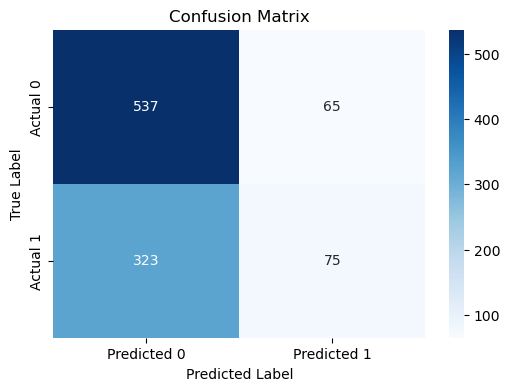


Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.89      0.73       602
           1       0.54      0.19      0.28       398

    accuracy                           0.61      1000
   macro avg       0.58      0.54      0.51      1000
weighted avg       0.59      0.61      0.55      1000



In [10]:
# Define divorce_model1 (Logistic Regression)
divorce_model1 = Pipeline(steps=[('preprocessor', preprocessor),('classifier', LogisticRegression(random_state=1))])
# Train the model
divorce_model1.fit(X_train, y_train) 

# Predict on the test set
y_pred = divorce_model1.predict(X_test) 
# Evaluation of the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print("\n--- Training Model (Logistic Regression Classifier) ---")

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', None)
print("Making predictions for the following 5 couples:")
print(X.head())
print("The predictions are")
print(divorce_model1.predict(X.head()))

print("\n--- Confusion Matrix ---")
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])    
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


print("\nClassification Report:")
print(classification_report(y_test, y_pred))



C:\Users\kabir\AppData\Local\Temp\ipykernel_29496\2019471720.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


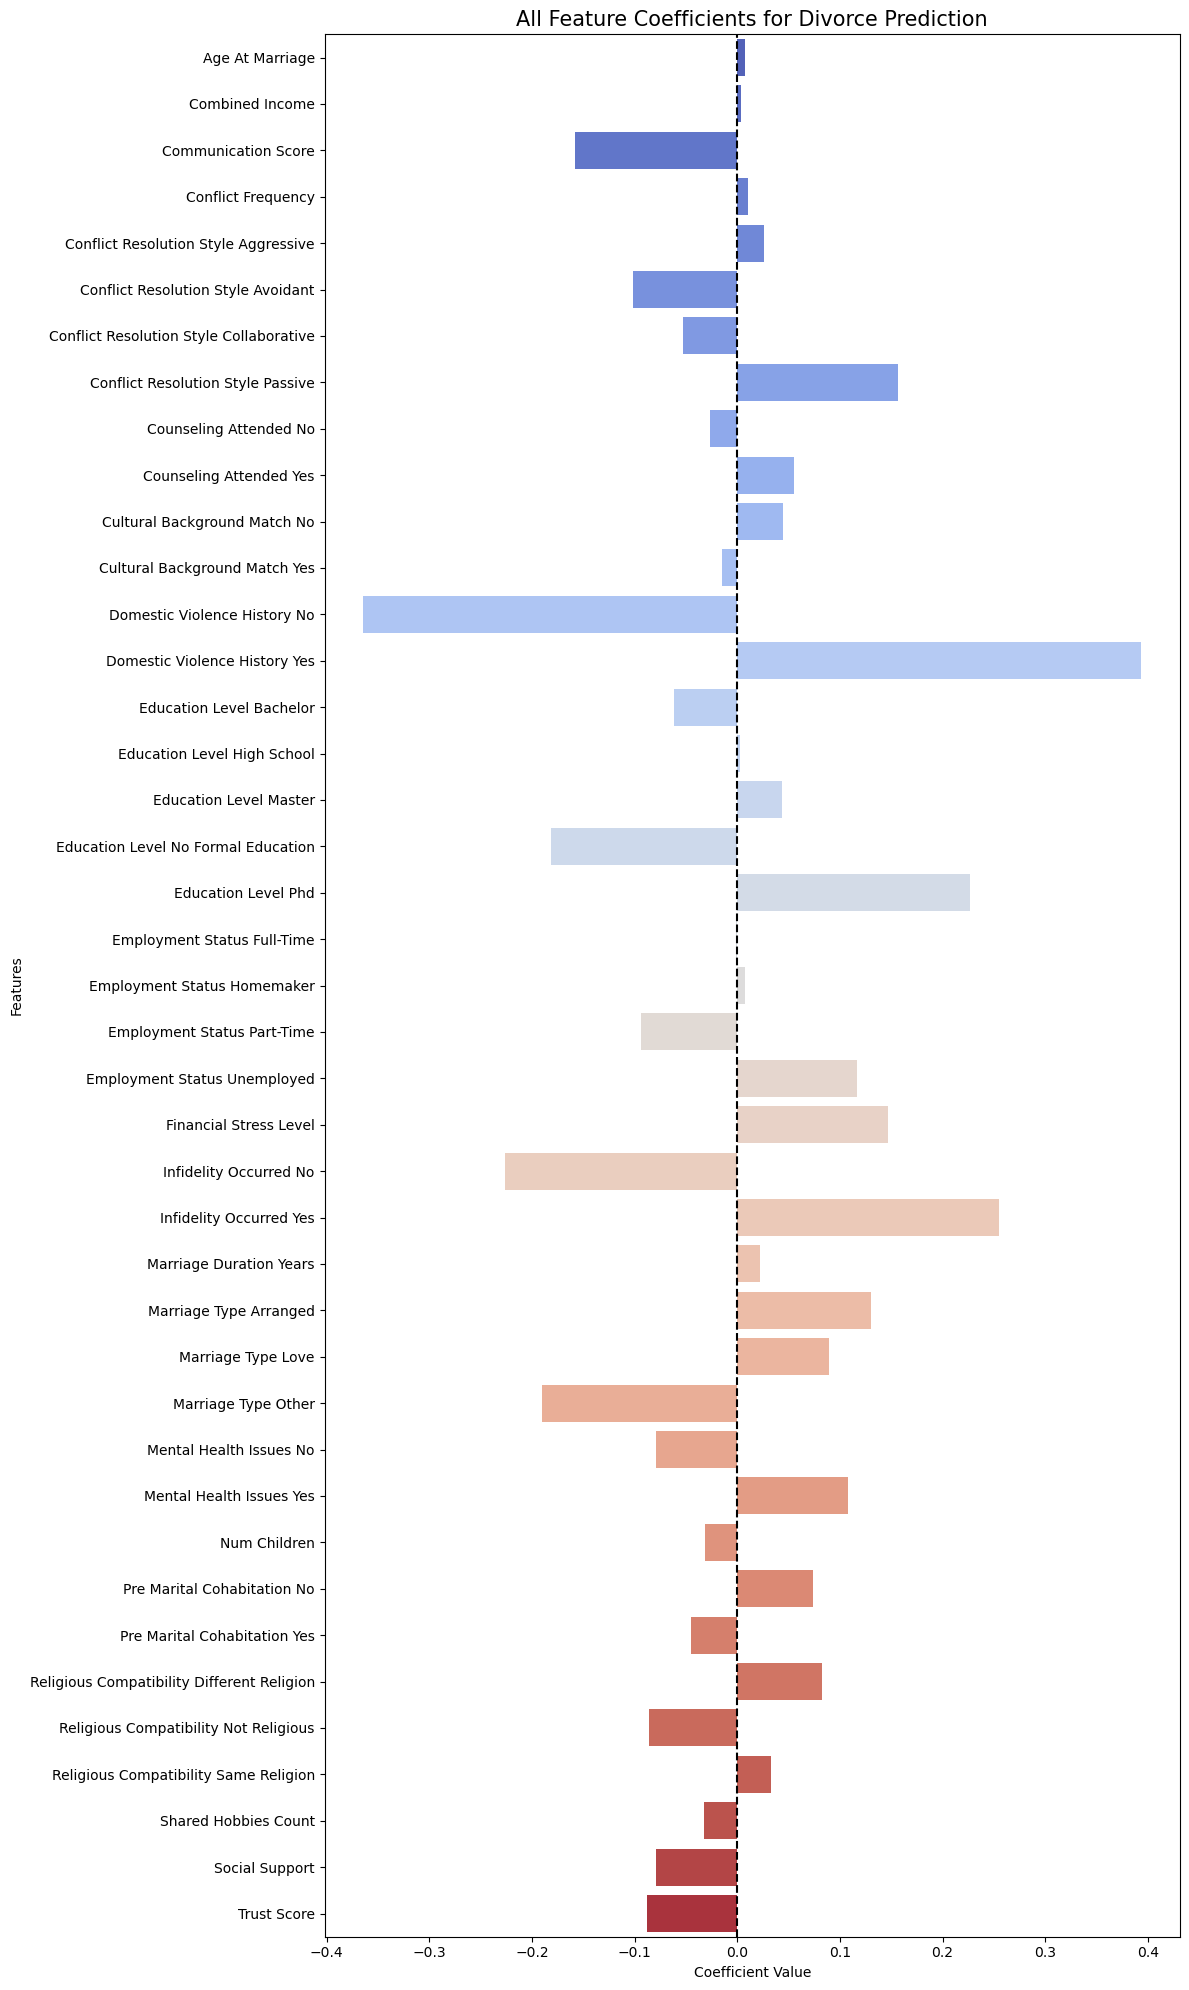

In [11]:
# Get model
logistic_model = divorce_model1.named_steps['classifier']

# Feature names
feature_names_num = numerical_features

feature_names_cat = divorce_model1.named_steps['preprocessor']\
    .named_transformers_['cat']\
    .get_feature_names_out(categorical_features)

all_feature_names = list(feature_names_num) + list(feature_names_cat)

# Coefficients
coefficients = logistic_model.coef_[0]

# Build dataframe
feature_importance = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': coefficients
})

# Make labels readable
plot_features = feature_importance.copy()
plot_features['Feature'] = (
    plot_features['Feature']
    .str.replace('_',' ')
    .str.title()
)

# Sort alphabetically
plot_features = plot_features.sort_values(by='Feature')

# Plot
plt.figure(figsize=(12,20))

sns.barplot(
    data=plot_features,
    x='Coefficient',
    y='Feature',
    palette='coolwarm'
)

plt.axvline(
    0,
    color='black',
    linestyle='--'
)

plt.title(
    'All Feature Coefficients for Divorce Prediction',
    fontsize=15
)

plt.xlabel(
    'Coefficient Value'
)

plt.ylabel(
    'Features'
)

plt.tight_layout()

plt.show()

Model2: Random Forest Classifier


--- Training Model (Random Forest Classifier) ---
Making predictions for the following 5 couples:
   age_at_marriage  marriage_duration_years  num_children      education_level employment_status  combined_income religious_compatibility cultural_background_match  communication_score  conflict_frequency conflict_resolution_style  financial_stress_level mental_health_issues infidelity_occurred counseling_attended  social_support  shared_hobbies_count marriage_type pre_marital_cohabitation domestic_violence_history  trust_score
0               30                        1             1             Bachelor         Full-time            64001      Different Religion                       Yes             5.536016                   3             Collaborative                6.026355                   No                  No                  No        8.428183                     5          Love                      Yes                        No     6.262411
1               27                   

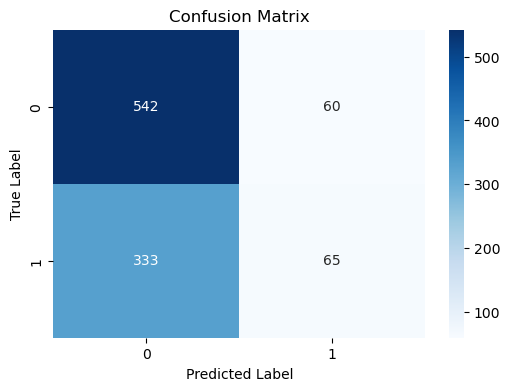


Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.90      0.73       602
           1       0.52      0.16      0.25       398

    accuracy                           0.61      1000
   macro avg       0.57      0.53      0.49      1000
weighted avg       0.58      0.61      0.54      1000



In [12]:
# Define divorce_model2 (Random Forest Classifier)
divorce_model2 = Pipeline(steps=[('preprocessor', preprocessor),('classifier', RandomForestClassifier(n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        random_state=42))])
# Train the model
divorce_model2.fit(X_train, y_train) 
# Predict on the test set
y_pred = divorce_model2.predict(X_test) 
# Evaluation of the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print("\n--- Training Model (Random Forest Classifier) ---")

print("Making predictions for the following 5 couples:")
print(X.head())
print("The predictions are")
print(divorce_model2.predict(X.head()))

print("\n--- Confusion Matrix ---")
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['0', '1'], yticklabels=['0', '1'])    
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


print("\nClassification Report:")
print(classification_report(y_test, y_pred))

C:\Users\kabir\AppData\Local\Temp\ipykernel_29496\2128857191.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


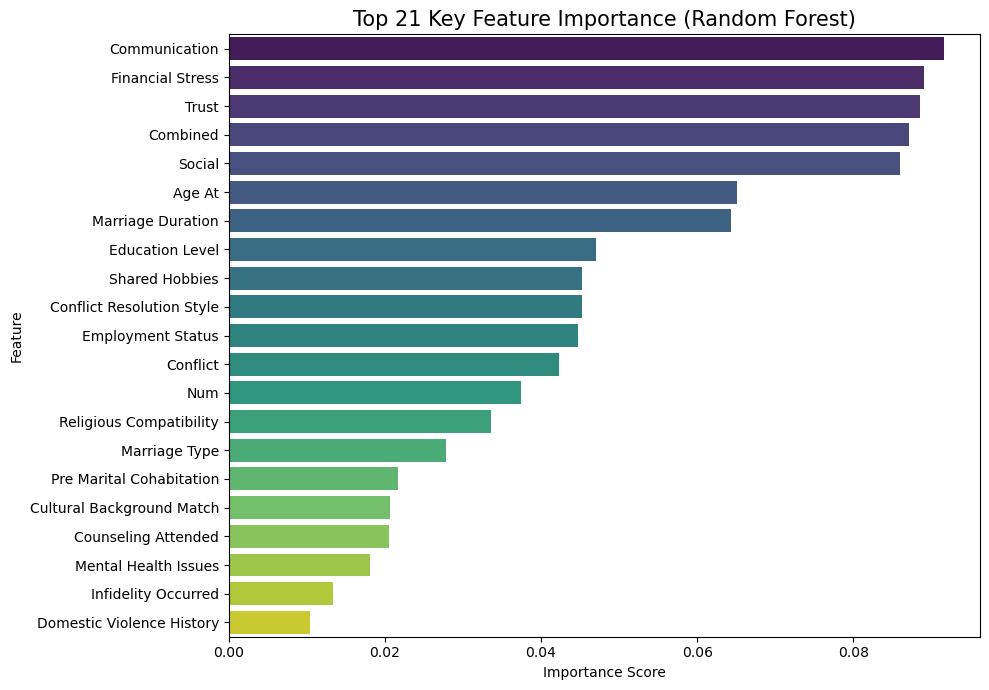

In [13]:
# Get trained Random Forest
rf_model = divorce_model2.named_steps['classifier']


# Get feature names
feature_names_num = numerical_features

feature_names_cat = divorce_model2.named_steps['preprocessor']\
    .named_transformers_['cat']\
    .get_feature_names_out(categorical_features)

all_feature_names = list(feature_names_num) + list(feature_names_cat)


# Importance
importance = rf_model.feature_importances_


feature_importance = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importance
})


# Clean names and combine all dummies for the same original feature
feature_importance['Feature'] = feature_importance['Feature'].apply(
    lambda x: x.rsplit('_', 1)[0].replace('_', ' ').title() if '_' in x else x.replace('_', ' ').title()
)


# Combine duplicated features by summing importance
feature_importance = (
    feature_importance
    .groupby('Feature', as_index=False)
    ['Importance']
    .sum()
)


# Sort by importance and select top 20
plot_features = feature_importance.sort_values(
    by='Importance',
    ascending=False
).head(21)


# Plot
plt.figure(figsize=(10,7))

sns.barplot(
    data=plot_features,
    x='Importance',
    y='Feature',
    palette='viridis'
)

plt.title(
    'Top 21 Key Feature Importance (Random Forest)',
    fontsize=15
)

plt.xlabel(
    'Importance Score'
)

plt.ylabel(
    'Feature'
)

plt.tight_layout()

plt.show()

Model3: XGBoost Classifier


--- Training Model (XGBoost Classifier) ---
Making predictions for the following 5 couples:
   age_at_marriage  marriage_duration_years  num_children      education_level employment_status  combined_income religious_compatibility cultural_background_match  communication_score  conflict_frequency conflict_resolution_style  financial_stress_level mental_health_issues infidelity_occurred counseling_attended  social_support  shared_hobbies_count marriage_type pre_marital_cohabitation domestic_violence_history  trust_score
0               30                        1             1             Bachelor         Full-time            64001      Different Religion                       Yes             5.536016                   3             Collaborative                6.026355                   No                  No                  No        8.428183                     5          Love                      Yes                        No     6.262411
1               27                        2

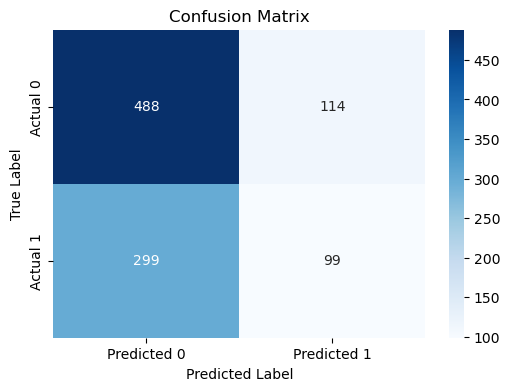


Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.81      0.70       602
           1       0.46      0.25      0.32       398

    accuracy                           0.59      1000
   macro avg       0.54      0.53      0.51      1000
weighted avg       0.56      0.59      0.55      1000



In [14]:
# Define divorce_model3 (Xgboost Classifier)
divorce_model3 = Pipeline(steps=[('preprocessor', preprocessor),('classifier', XGBClassifier(n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss'))])
# Train the model
divorce_model3.fit(X_train, y_train) 
# Predict on the test set
y_pred = divorce_model3.predict(X_test) 
# Evaluation of the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print("\n--- Training Model (XGBoost Classifier) ---")

print("Making predictions for the following 5 couples:")
print(X.head())
print("The predictions are")
print(divorce_model3.predict(X.head()))

print("\n--- Confusion Matrix ---")
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])    
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


print("\nClassification Report:")
print(classification_report(y_test, y_pred))

C:\Users\kabir\AppData\Local\Temp\ipykernel_29496\3597498131.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


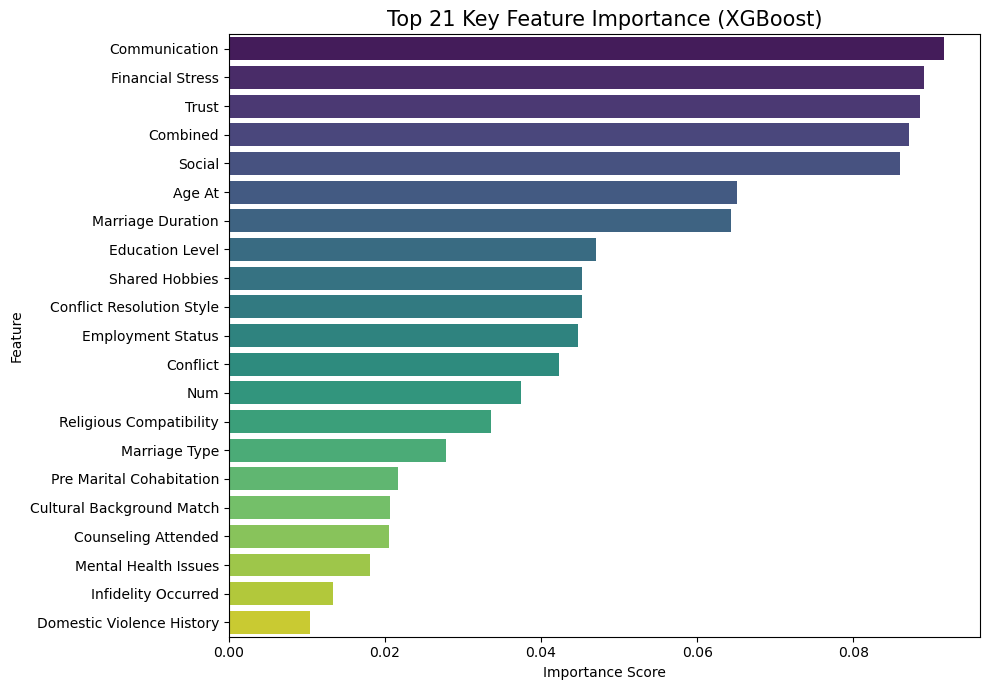

In [15]:
# Get trained XGBoost
xgb_model = divorce_model3.named_steps['classifier']


# Get feature names
feature_names_num = numerical_features

feature_names_cat = divorce_model3.named_steps['preprocessor']\
    .named_transformers_['cat']\
    .get_feature_names_out(categorical_features)

all_feature_names = list(feature_names_num) + list(feature_names_cat)


# Importance
importance = rf_model.feature_importances_


feature_importance = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importance
})


# Clean names and combine all dummies for the same original feature
feature_importance['Feature'] = feature_importance['Feature'].apply(
    lambda x: x.rsplit('_', 1)[0].replace('_', ' ').title() if '_' in x else x.replace('_', ' ').title()
)


# Combine duplicated features by summing importance
feature_importance = (
    feature_importance
    .groupby('Feature', as_index=False)
    ['Importance']
    .sum()
)


# Sort by importance and select top 20
plot_features = feature_importance.sort_values(
    by='Importance',
    ascending=False
).head(21)


# Plot
plt.figure(figsize=(10,7))

sns.barplot(
    data=plot_features,
    x='Importance',
    y='Feature',
    palette='viridis'
)

plt.title(
    'Top 21 Key Feature Importance (XGBoost)',
    fontsize=15
)

plt.xlabel(
    'Importance Score'
)

plt.ylabel(
    'Feature'
)

plt.tight_layout()

plt.show()

## Deep Learning

Model 1: Neural Network  with 32 neurons

In [16]:
# Starting from the output of the preprocessing pipeline
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [17]:
# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_processed, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_processed, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

In [18]:
# Use PROCESSED input size (IMPORTANT)
input_size = X_train_tensor.shape[1]

model_32 = nn.Sequential(
    nn.Linear(input_size, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 1),
    nn.Sigmoid()
)

In [19]:
#Loss and Optimization
criterion = nn.BCELoss()
optimizer = optim.Adam(model_32.parameters(), lr=0.001)

In [20]:
# Training loop
train_losses = []
epochs = 100

for epoch in range(epochs):
    model_32.train()
    optimizer.zero_grad()
    
    outputs = model_32(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())
    
    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

Epoch [10/100], Loss: 0.6725
Epoch [20/100], Loss: 0.6692
Epoch [30/100], Loss: 0.6658
Epoch [40/100], Loss: 0.6617
Epoch [50/100], Loss: 0.6573
Epoch [60/100], Loss: 0.6534
Epoch [70/100], Loss: 0.6496
Epoch [80/100], Loss: 0.6457
Epoch [90/100], Loss: 0.6416
Epoch [100/100], Loss: 0.6370


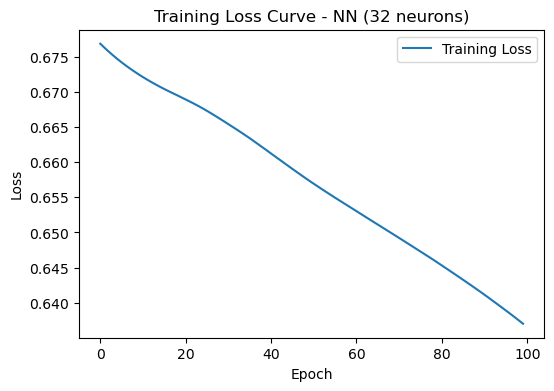

In [21]:
#Loss curve
plt.figure(figsize=(6, 4))
plt.plot(train_losses, label='Training Loss')

plt.title('Training Loss Curve - NN (32 neurons)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [22]:
# evaluation
model_32.eval()
with torch.no_grad():
    y_pred_prob = model_32(X_test_tensor).squeeze()
    y_pred = (y_pred_prob >= 0.5).float()


--- Predictions for the first 5 couples ---
   age_at_marriage  marriage_duration_years  num_children      education_level employment_status  combined_income religious_compatibility cultural_background_match  communication_score  conflict_frequency conflict_resolution_style  financial_stress_level mental_health_issues infidelity_occurred counseling_attended  social_support  shared_hobbies_count marriage_type pre_marital_cohabitation domestic_violence_history  trust_score
0               30                        1             1             Bachelor         Full-time            64001      Different Religion                       Yes             5.536016                   3             Collaborative                6.026355                   No                  No                  No        8.428183                     5          Love                      Yes                        No     6.262411
1               27                        2             2               Master         Full

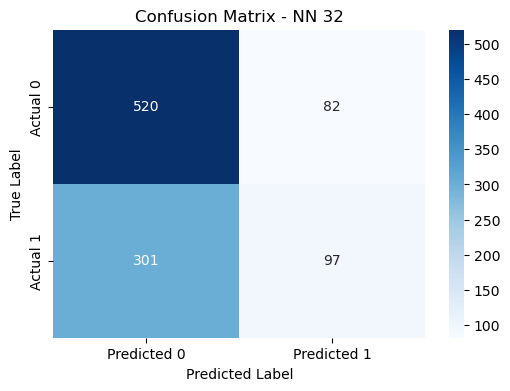


Classification Report:
              precision    recall  f1-score   support

         0.0       0.63      0.86      0.73       602
         1.0       0.54      0.24      0.34       398

    accuracy                           0.62      1000
   macro avg       0.59      0.55      0.53      1000
weighted avg       0.60      0.62      0.57      1000



In [23]:
#Displaying scenarios for the first 5 couples
print("\n--- Predictions for the first 5 couples ---")
print(X.head())
print("The predictions are")
with torch.no_grad():
    X_head_processed = preprocessor.transform(X.head())
    X_head_tensor = torch.tensor(X_head_processed, dtype=torch.float32)
    head_pred_prob = model_32(X_head_tensor).squeeze()
    head_pred = (head_pred_prob >= 0.5).float()
print(head_pred.numpy())
conf_matrix = confusion_matrix(y_test_tensor.numpy(), y_pred.numpy())
print("\n--- Deep Feed Forward Neural Network Model_32 ---")


# Display confusion matrix to analyze classification performance

print("\n--- Confusion Matrix ---")
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title("Confusion Matrix - NN 32")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()
print("\nClassification Report:")
print(classification_report(y_test_tensor.numpy(), y_pred.numpy()))

Model 2: Neural Network  with 64 neurons

In [24]:
# Model 64
input_size = X_train_processed.shape[1]
model_64 = nn.Sequential(
    nn.Linear(input_size, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 1),
    nn.Sigmoid()    
)

In [25]:
#Loss and Optimization
criterion = nn.BCELoss()
optimizer = optim.Adam(model_64.parameters(), lr=0.001)

In [26]:
# Training loop
epochs = 100
train_losses = []
for epoch in range(epochs):
    model_64.train()
    optimizer.zero_grad()
    
    outputs = model_64(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())
    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

Epoch [10/100], Loss: 0.7053
Epoch [20/100], Loss: 0.6910
Epoch [30/100], Loss: 0.6727
Epoch [40/100], Loss: 0.6695
Epoch [50/100], Loss: 0.6652
Epoch [60/100], Loss: 0.6626
Epoch [70/100], Loss: 0.6599
Epoch [80/100], Loss: 0.6569
Epoch [90/100], Loss: 0.6537
Epoch [100/100], Loss: 0.6498


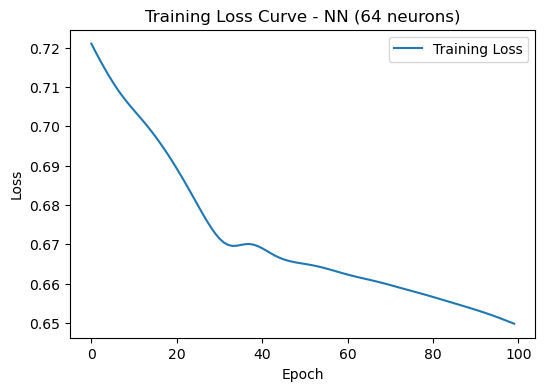

In [27]:
#Loss curve
plt.figure(figsize=(6, 4))
plt.plot(train_losses, label='Training Loss')

plt.title('Training Loss Curve - NN (64 neurons)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [28]:
# evaluation
model_64.eval()
with torch.no_grad():
    y_pred_prob = model_64(X_test_tensor).squeeze()
    y_pred = (y_pred_prob >= 0.5).float()


--- Predictions for the first 5 couples ---
   age_at_marriage  marriage_duration_years  num_children      education_level employment_status  combined_income religious_compatibility cultural_background_match  communication_score  conflict_frequency conflict_resolution_style  financial_stress_level mental_health_issues infidelity_occurred counseling_attended  social_support  shared_hobbies_count marriage_type pre_marital_cohabitation domestic_violence_history  trust_score
0               30                        1             1             Bachelor         Full-time            64001      Different Religion                       Yes             5.536016                   3             Collaborative                6.026355                   No                  No                  No        8.428183                     5          Love                      Yes                        No     6.262411
1               27                        2             2               Master         Full

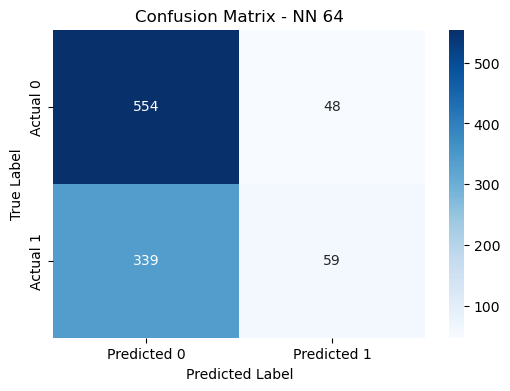


Classification Report:
              precision    recall  f1-score   support

         0.0       0.62      0.92      0.74       602
         1.0       0.55      0.15      0.23       398

    accuracy                           0.61      1000
   macro avg       0.59      0.53      0.49      1000
weighted avg       0.59      0.61      0.54      1000



In [29]:
#Displaying scenarios for the first 5 couples
print("\n--- Predictions for the first 5 couples ---")
print(X.head(5))
print("The predictions are")
with torch.no_grad():
    X_head_processed = preprocessor.transform(X.head(5))
    X_head_tensor = torch.tensor(X_head_processed, dtype=torch.float32)
    head_pred_prob = model_64(X_head_tensor).squeeze()
    head_pred = (head_pred_prob >= 0.5).float()
print(head_pred.numpy())

conf_matrix = confusion_matrix(y_test_tensor.numpy(), y_pred.numpy())
print("\n--- Deep Feed Forward Neural Network Model_64 ---")

# Display confusion matrix to analyze classification performance

print("\n--- Confusion Matrix ---")
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title("Confusion Matrix - NN 64")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()
print("\nClassification Report:")
print(classification_report(y_test_tensor.numpy(), y_pred.numpy()))

TabNet

In [30]:
# Convert preprocessed data to the format required by TabNet
X_train_tabnet = X_train_processed
X_test_tabnet = X_test_processed

y_train_tabnet = y_train.to_numpy().ravel()
y_test_tabnet = y_test.to_numpy().ravel()

In [31]:
#Define TabNet Classifier
tabnet = TabNetClassifier(
    n_d=16,  # Dimension of the decision prediction layer
    n_a=16,  # Dimension of the attention embedding for each mask   
    n_steps=7,  # Number of steps in the architecture
    gamma=1.5,  # Relaxation parameter for the sparsemax
    lambda_sparse=1e-4,  # Sparsity regularization strength
)

tabnet.fit(X_train_tabnet, y_train_tabnet,
           eval_set=[(X_test_tabnet, y_test_tabnet)], 
           eval_metric=['auc'],
           max_epochs=100, 
           patience=10, 
           batch_size=256, 
           virtual_batch_size=128
           )

c:\Users\kabir\miniforge3\envs\DSPy2025\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.99142 | val_0_auc: 0.48956 |  0:00:02s
epoch 1  | loss: 0.77045 | val_0_auc: 0.5066  |  0:00:05s
epoch 2  | loss: 0.73183 | val_0_auc: 0.49218 |  0:00:07s
epoch 3  | loss: 0.70541 | val_0_auc: 0.48731 |  0:00:10s
epoch 4  | loss: 0.70369 | val_0_auc: 0.51148 |  0:00:12s
epoch 5  | loss: 0.67785 | val_0_auc: 0.5213  |  0:00:15s
epoch 6  | loss: 0.67759 | val_0_auc: 0.49797 |  0:00:17s
epoch 7  | loss: 0.67613 | val_0_auc: 0.52576 |  0:00:20s
epoch 8  | loss: 0.67314 | val_0_auc: 0.52403 |  0:00:22s
epoch 9  | loss: 0.67525 | val_0_auc: 0.53882 |  0:00:25s
epoch 10 | loss: 0.67373 | val_0_auc: 0.53202 |  0:00:27s
epoch 11 | loss: 0.66944 | val_0_auc: 0.53628 |  0:00:30s
epoch 12 | loss: 0.66956 | val_0_auc: 0.55242 |  0:00:32s
epoch 13 | loss: 0.66669 | val_0_auc: 0.54818 |  0:00:34s
epoch 14 | loss: 0.67314 | val_0_auc: 0.54948 |  0:00:37s
epoch 15 | loss: 0.66922 | val_0_auc: 0.53855 |  0:00:39s
epoch 16 | loss: 0.66775 | val_0_auc: 0.53347 |  0:00:42s
epoch 17 | los

c:\Users\kabir\miniforge3\envs\DSPy2025\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



--- Predictions for the first 5 couples ---
   age_at_marriage  marriage_duration_years  num_children      education_level employment_status  combined_income religious_compatibility cultural_background_match  communication_score  conflict_frequency conflict_resolution_style  financial_stress_level mental_health_issues infidelity_occurred counseling_attended  social_support  shared_hobbies_count marriage_type pre_marital_cohabitation domestic_violence_history  trust_score
0               30                        1             1             Bachelor         Full-time            64001      Different Religion                       Yes             5.536016                   3             Collaborative                6.026355                   No                  No                  No        8.428183                     5          Love                      Yes                        No     6.262411
1               27                        2             2               Master         Full

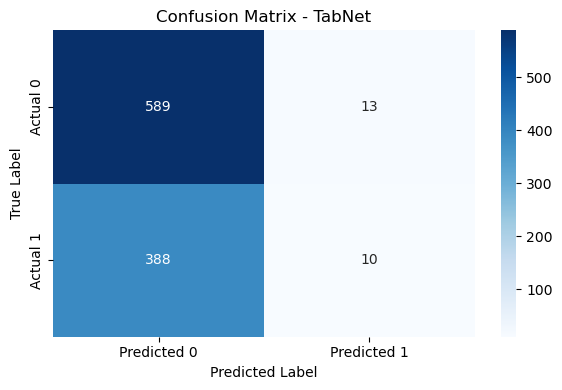


Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.98      0.75       602
           1       0.43      0.03      0.05       398

    accuracy                           0.60      1000
   macro avg       0.52      0.50      0.40      1000
weighted avg       0.54      0.60      0.47      1000



In [32]:
print("\n--- Predictions for the first 5 couples ---")

# Show raw data
print(X.head())

# Preprocess
X_head_processed = preprocessor.transform(X.head())

# TabNet expects NumPy
head_pred_prob = tabnet.predict_proba(X_head_processed)[:, 1]

# Convert to binary
head_pred = (head_pred_prob >= 0.5).astype(int)

print("The predictions are ")
print(head_pred)

# Predictions on test set
y_pred_tabnet = tabnet.predict(X_test_tabnet)

# Confusion matrix
conf_matrix_tabnet = confusion_matrix(y_test_tabnet, y_pred_tabnet)

print("\n--- TabNet Classifier ---")
print("\n--- Confusion Matrix ---")

plt.figure(figsize=(6, 4))

sns.heatmap(
    conf_matrix_tabnet,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted 0', 'Predicted 1'],
    yticklabels=['Actual 0', 'Actual 1']
)

plt.title("Confusion Matrix - TabNet")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

# Classification report
print("\nClassification Report:")
print(classification_report(y_test_tabnet, y_pred_tabnet))

ROC-AUC Curve(Model Performance)

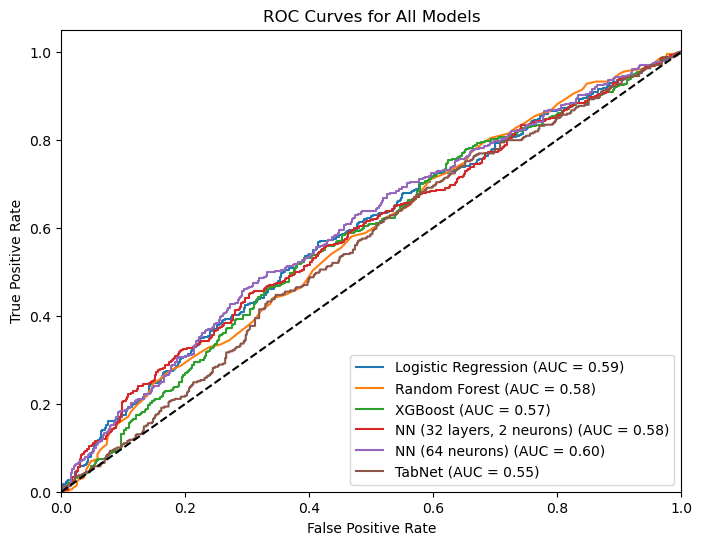


--- Classification Report Overview ---
                       Model  Accuracy  Precision  Recall  F1-Score     AUC
0        Logistic Regression     0.612     0.5357  0.1884    0.2788  0.5873
1              Random Forest     0.607     0.5200  0.1633    0.2486  0.5769
2                    XGBoost     0.587     0.4648  0.2487    0.3241  0.5746
3  NN (32 layers, 2 neurons)     0.617     0.5419  0.2437    0.3362  0.5838
4            NN (64 neurons)     0.613     0.5514  0.1482    0.2337  0.5972
5                     TabNet     0.599     0.4348  0.0251    0.0475  0.5524


In [33]:
#extract trained classifiers from pipelines for ROC curve
logistic_pipeline = divorce_model1
random_forest_pipeline = divorce_model2
xgb_pipeline = divorce_model3

plt.figure(figsize=(8, 6))

X_test_nn = X_test_tensor

#Logistic Regression
y_prob_lr = logistic_pipeline.predict_proba(X_test)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = auc(fpr_lr, tpr_lr)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.2f})')

#Random Forest
y_prob_rf = random_forest_pipeline.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})')

#XGBoost
y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
auc_xgb = auc(fpr_xgb, tpr_xgb)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.2f})')

# Neural Network 32 layers
y_prob_nn_32 = model_32(X_test_nn).detach().numpy().ravel()
fpr_nn_32, tpr_nn_32, _ = roc_curve(y_test_tensor.numpy(), y_prob_nn_32)
auc_nn_32 = auc(fpr_nn_32, tpr_nn_32)
plt.plot(fpr_nn_32, tpr_nn_32, label=f'NN (32 layers, 2 neurons) (AUC = {auc_nn_32:.2f})')

# Neural Network 64 neurons
y_prob_nn_64 = model_64(X_test_nn).detach().numpy().ravel()
fpr_nn_64, tpr_nn_64, _ = roc_curve(y_test_tensor.numpy(), y_prob_nn_64)
auc_nn_64 = auc(fpr_nn_64, tpr_nn_64)
plt.plot(fpr_nn_64, tpr_nn_64, label=f'NN (64 neurons) (AUC = {auc_nn_64:.2f})')

# TabNet
y_prob_tabnet = tabnet.predict_proba(X_test_tabnet)[:, 1]
fpr_tabnet, tpr_tabnet, _ = roc_curve(y_test_tabnet, y_prob_tabnet)
auc_tabnet = auc(fpr_tabnet, tpr_tabnet)
plt.plot(fpr_tabnet, tpr_tabnet, label=f'TabNet (AUC = {auc_tabnet:.2f})')

# Roc curve settings
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line for random guessing
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title('ROC Curves for All Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

# Overview of Classification Reports
models = {
    'Logistic Regression': divorce_model1.predict(X_test),
    'Random Forest': divorce_model2.predict(X_test),
    'XGBoost': divorce_model3.predict(X_test),
    'NN (32 layers, 2 neurons)': (model_32(X_test_nn).detach().numpy().ravel() >= 0.5).astype(int),
    'NN (64 neurons)': (model_64(X_test_nn).detach().numpy().ravel() >= 0.5).astype(int),
    'TabNet': tabnet.predict(X_test_tabnet)
}

y_test_np = y_test.values

summary = []
for name, y_pred in models.items():
    acc = accuracy_score(y_test_np, y_pred)
    prec = precision_score(y_test_np, y_pred)
    rec = recall_score(y_test_np, y_pred)
    f1 = f1_score(y_test_np, y_pred)
    auc_val = auc_lr if name == 'Logistic Regression' else auc_rf if name == 'Random Forest' else auc_xgb if name == 'XGBoost' else auc_nn_32 if '32 layers' in name else auc_nn_64 if '64 neurons' in name else auc_tabnet
    summary.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1, 'AUC': auc_val})

summary_df = pd.DataFrame(summary)
print("\n--- Classification Report Overview ---")
print(summary_df.round(4))